# Task 2: Painting Similarity Search

**ArtExtract — GSoC 2025 Evaluation Task**

---

## Overview

This notebook builds a pipeline to **find visual similarities in paintings** — e.g., portraits sharing a similar face, pose, or compositional layout — using the [National Gallery of Art open dataset](https://github.com/NationalGalleryOfArt/opendata).

### Strategy

Finding similarity across paintings requires a **rich visual embedding** that captures both low-level features (color palette, brushstroke texture) and high-level semantic content (compositional structure). The chosen implemented approach combines:

1. **Feature Extraction** — DINO ViT-B/16 (self-supervised Vision Transformer), which produces expressive patch-level embeddings without requiring labeled data, making it ideal for the diverse domain of fine art.
2. **Approximate Nearest Neighbour search** — FAISS (Facebook AI Similarity Search) with L2 distance, which scales to thousands of embeddings with sub-second retrieval.
3. **Data Verification Pipeline** — A robust filtering mechanism to ensure strict alignment between the `published_images.csv` metadata and the actually downloaded/available files in the local directory.

*(Note: While pose-aware similarity via MediaPipe and facial recognition via FaceNet are valuable for granular searches, the current core pipeline relies on DINO's global semantic features as a robust baseline).*

### Evaluation Metrics
- **Mean Precision@K** — Evaluates the fraction of the top-K retrieved images that share the exact same artist (`attribution`) as the query, acting as a proxy for visual similarity.
- **Mean Average Precision (mAP)** — Standard retrieval benchmark to account for the rank position of relevant matches.
- **Qualitative gallery** — Side-by-side display of query and retrieved paintings.

---
## 1. Environment Setup & Library Imports

In [1]:
# ── Core scientific stack ────────────────────────────────────────────────────
import os
import random
import warnings
import json
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm

# ── PyTorch & torchvision ────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ── Image utilities ──────────────────────────────────────────────────────────
from PIL import Image

# ── Approximate nearest-neighbour search ─────────────────────────────────────
import faiss

# ── Sklearn ──────────────────────────────────────────────────────────────────
from sklearn.manifold import TSNE
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import normalize

warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu126


---
## 2. Dataset: National Gallery of Art Open Data

The [NGA Open Data repository](https://github.com/NationalGalleryOfArt/opendata) provides CSV files containing artwork metadata and IIIF image manifests. Key files:

| File | Contents |
|---|---|
| `objects.csv` | objectid, title, classification, medium, attribution (artist), dated |
| `published_images.csv` | objectid, uuid, viewtype → IIIF URL for high-res image download |

Images are served via the IIIF protocol:
```
https://api.nga.gov/iiif/{uuid}/full/!400,400/0/default.jpg
```

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# Update DATA_ROOT to wherever you cloned / extracted the NGA opendata repo.
DATA_ROOT = Path("opendata")
OBJECTS_CSV = DATA_ROOT / "data" / "objects.csv"
IMAGES_CSV = DATA_ROOT / "data" / "published_images.csv"
IMG_DIR = DATA_ROOT / "images"  # downloaded images go here
EMBED_CACHE = DATA_ROOT / "embeddings.npy"

IMG_DIR.mkdir(parents=True, exist_ok=True)

# IIIF image URL template (400×400 thumbnail)
IIIF_TEMPLATE = "https://api.nga.gov/iiif/{uuid}/full/!400,400/0/default.jpg"

# Hyper-parameters
IMG_SIZE = 224
BATCH_SIZE = 32
TOP_K = 10  # number of similar images to retrieve

print("Paths configured.")

Paths configured.


In [3]:
def load_nga_metadata(
    objects_csv: Path, images_csv: Path, demo_rows: int = 300
) -> pd.DataFrame:
    """Load and merge NGA metadata. Falls back to synthetic demo data if not found."""

    def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        out.columns = (
            out.columns.astype(str)
            .str.strip()
            .str.lower()
            .str.replace(r"[^a-z0-9]+", "", regex=True)
        )
        return out

    def _pick_first_existing(df: pd.DataFrame, candidates) -> str | None:
        for col in candidates:
            if col in df.columns:
                return col
        return None

    def _norm_series(s: pd.Series) -> pd.Series:
        return s.fillna("").astype(str).str.strip().str.lower()

    if objects_csv.exists() and images_csv.exists():
        obj_df = _normalize_columns(
            pd.read_csv(objects_csv, dtype=str, low_memory=False)
        )
        img_df = _normalize_columns(
            pd.read_csv(images_csv, dtype=str, low_memory=False)
        )

        obj_id_col_obj = _pick_first_existing(
            obj_df, ["objectid", "objectnumber", "id"]
        )
        obj_id_col_img = _pick_first_existing(
            img_df, ["depictstmsobjectid", "objectid", "objectnumber", "id"]
        )
        uuid_col_obj = _pick_first_existing(obj_df, ["uuid", "imageuuid", "iiifuuid"])
        uuid_col_img = _pick_first_existing(img_df, ["uuid", "imageuuid", "iiifuuid"])
        url_col_img = _pick_first_existing(
            img_df, ["iiifthumburl", "iiifurl", "imageurl"]
        )
        viewtype_col = _pick_first_existing(img_df, ["viewtype", "view"])

        if viewtype_col is not None:
            primary_mask = img_df[viewtype_col].fillna("").str.lower().eq("primary")
            if primary_mask.any():
                img_df = img_df[primary_mask]

        df = None

        # Preferred path for current NGA schema: objectid <-> depictstmsobjectid
        if obj_id_col_obj is not None and obj_id_col_img is not None:
            obj_df["_obj_key"] = _norm_series(obj_df[obj_id_col_obj])
            img_df["_obj_key"] = _norm_series(img_df[obj_id_col_img])
            img_df = img_df[img_df["_obj_key"] != ""].drop_duplicates("_obj_key")

            keep_cols = ["_obj_key"]
            if uuid_col_img is not None:
                keep_cols.append(uuid_col_img)
            if url_col_img is not None:
                keep_cols.append(url_col_img)

            df = obj_df.merge(img_df[keep_cols], on="_obj_key", how="inner")
            df = df.drop(columns=["_obj_key"])

            if obj_id_col_obj != "objectid":
                df = df.rename(columns={obj_id_col_obj: "objectid"})
            if uuid_col_img is not None and uuid_col_img != "uuid":
                df = df.rename(columns={uuid_col_img: "uuid"})
            if url_col_img is not None and url_col_img != "image_url":
                df = df.rename(columns={url_col_img: "image_url"})

        # Fallback: UUID-based merge when object-id link is unavailable
        if (
            (df is None or len(df) == 0)
            and uuid_col_obj is not None
            and uuid_col_img is not None
        ):
            obj_df["_uuid_key"] = _norm_series(obj_df[uuid_col_obj])
            img_df["_uuid_key"] = _norm_series(img_df[uuid_col_img])
            img_df = img_df[img_df["_uuid_key"] != ""].drop_duplicates("_uuid_key")

            keep_cols = ["_uuid_key"]
            if url_col_img is not None:
                keep_cols.append(url_col_img)

            df = obj_df.merge(img_df[keep_cols], on="_uuid_key", how="inner")
            df = df.drop(columns=["_uuid_key"])
            if uuid_col_obj != "uuid":
                df = df.rename(columns={uuid_col_obj: "uuid"})
            if url_col_img is not None and url_col_img != "image_url":
                df = df.rename(columns={url_col_img: "image_url"})

        # Last-resort fallback: use objects.csv rows that contain uuid
        if (df is None or len(df) == 0) and uuid_col_obj is not None:
            obj_df["uuid"] = _norm_series(obj_df[uuid_col_obj])
            df = obj_df[obj_df["uuid"] != ""].copy()
            if obj_id_col_obj is not None and obj_id_col_obj != "objectid":
                df = df.rename(columns={obj_id_col_obj: "objectid"})

        if df is not None and len(df) > 0:
            if "objectid" not in df.columns:
                df["objectid"] = np.arange(len(df)).astype(str)

            if "uuid" in df.columns:
                df["uuid"] = _norm_series(df["uuid"])

            if "image_url" not in df.columns or df["image_url"].isna().all():
                if "uuid" in df.columns:
                    df["image_url"] = df["uuid"].apply(
                        lambda u: IIIF_TEMPLATE.format(uuid=u)
                    )
                else:
                    print("[WARN] No URL source found; falling back to demo metadata.")
                    df = None

            if df is not None:
                if "uuid" in df.columns:
                    df["local_path"] = df["uuid"].apply(
                        lambda u: str(IMG_DIR / f"{u}.jpg")
                    )
                else:
                    df["local_path"] = df["objectid"].apply(
                        lambda o: str(IMG_DIR / f"obj_{o}.jpg")
                    )
                return df.reset_index(drop=True)

    print(f"[DEMO] NGA data not found — generating synthetic metadata.")
    rng = np.random.default_rng(SEED)
    classifications = ["painting", "drawing", "sculpture", "photograph", "print"]
    return pd.DataFrame(
        {
            "objectid": [str(i) for i in range(demo_rows)],
            "title": [f"Artwork {i}" for i in range(demo_rows)],
            "classification": rng.choice(classifications, demo_rows),
            "attribution": [f"Artist {rng.integers(0, 50)}" for _ in range(demo_rows)],
            "dated": [str(rng.integers(1400, 1900)) for _ in range(demo_rows)],
            "uuid": [f"uuid_{i:06d}" for i in range(demo_rows)],
            "image_url": [
                IIIF_TEMPLATE.format(uuid=f"uuid_{i:06d}") for i in range(demo_rows)
            ],
            "local_path": [
                str(IMG_DIR / f"uuid_{i:06d}.jpg") for i in range(demo_rows)
            ],
        }
    )


df = load_nga_metadata(OBJECTS_CSV, IMAGES_CSV)
print(f"Total artworks with images: {len(df)}")
df

Total artworks with images: 118072


,objectid,uuid_x,accessioned,accessionnum,locationid,title,displaydate,beginyear,endyear,visualbrowsertimespan,...,portfolio,series,volume,watermarks,lastdetectedmodification,wikidataid,customprinturl,uuid_y,image_url,local_path
0,0,b5dc500c-be86-4b05-93fa-59a25d8775fb,1,1937.1.2.c,NaN,Saint James Major,c. 1310,1310,1310,1300 to 1400,...,NaN,NaN,NaN,NaN,2023-05-09 17:01:03.48-04,Q20172973,NaN,7b170a4c-9d44-475c-b294-cee6f43d88af,https://api.nga.gov/iiif/7b170a4c-9d44-475c-b2...,opendata\images\obj_0.jpg
1,1,59e0e07c-208e-4d24-a3d3-f4a56d20d6d3,1,1937.1.3,NaN,Saint Paul and a Group of Worshippers,1333,1333,1333,1300 to 1400,...,NaN,NaN,NaN,NaN,2024-02-12 16:33:23.167-05,Q20173083,NaN,7bbcfd01-e774-46e7-96d1-a3b03598cd8a,https://api.nga.gov/iiif/7bbcfd01-e774-46e7-96...,opendata\images\obj_1.jpg
2,2,95cfbfd3-5947-4834-b1cf-bf92ee1a7340,1,1937.1.4.a,8198,Saint Andrew and Saint Benedict with the Archa...,shortly before 1387,1387,1387,1300 to 1400,...,NaN,NaN,NaN,NaN,2024-03-08 14:32:09.57-05,Q20173290,NaN,e8a1acb4-f60a-477a-9bfe-61fa5072c514,https://api.nga.gov/iiif/e8a1acb4-f60a-477a-9b...,opendata\images\obj_2.jpg
3,3,3277a6d0-d92e-4684-9d86-2be2cbe3c5f2,1,1937.1.4.b,8198,Madonna and Child Enthroned with Twelve Angels...,shortly before 1387,1387,1387,1300 to 1400,...,NaN,NaN,NaN,NaN,2024-03-08 14:32:09.57-05,Q20173280,NaN,abec1c5b-ee32-450d-9398-5c84f1f8cf14,https://api.nga.gov/iiif/abec1c5b-ee32-450d-93...,opendata\images\obj_3.jpg
4,4,63225dec-d421-4ece-9f2a-335dd2dfeea1,1,1937.1.4.c,8198,Saint Bernard and Saint Catherine of Alexandri...,shortly before 1387,1387,1387,1300 to 1400,...,NaN,NaN,NaN,NaN,2024-03-08 14:32:09.57-05,Q20173299,NaN,e6890364-4d99-4684-a62b-5060ee3c3446,https://api.nga.gov/iiif/e6890364-4d99-4684-a6...,opendata\images\obj_4.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118067,232394,855bd720-6f52-4ccb-b1db-88627833ce84,1,2025.100.139,NaN,Mountain Climbing,c. 1931,1926,1936,1926 to 1950,...,NaN,NaN,NaN,NaN,2026-02-13 22:01:41.52-05,NaN,NaN,44592721-9d74-4a4b-bf29-fa98c3dd8300,https://api.nga.gov/iiif/44592721-9d74-4a4b-bf...,opendata\images\obj_232394.jpg
118068,232395,24261666-f42a-45ad-9cad-0aa6eb88c4c9,1,2025.100.140,NaN,Die Opelbrücke über den Urselbach (The Opel-Br...,c. 1931,1926,1936,1926 to 1950,...,NaN,NaN,NaN,NaN,2026-02-13 22:01:41.52-05,NaN,NaN,10ba0e2d-17ae-4fac-91c6-e3b0c2d8d36e,https://api.nga.gov/iiif/10ba0e2d-17ae-4fac-91...,opendata\images\obj_232395.jpg
118069,232396,85d83d4b-477b-4f99-89a4-bc184fdf4d37,1,2025.100.141,NaN,Portrait of a Man,c. 1931,1926,1936,1926 to 1950,...,NaN,NaN,NaN,NaN,2026-02-13 22:01:41.52-05,NaN,NaN,28ea9ec6-b1e4-45a7-babf-f0d2cc58cfef,https://api.nga.gov/iiif/28ea9ec6-b1e4-45a7-ba...,opendata\images\obj_232396.jpg
118070,233932,01e21be8-2ef9-4f30-9580-e6b99b867327,1,2025.101.2.1-50,NaN,Genesis,2005,2005,2005,2001 to present,...,Genesis,NaN,NaN,NaN,2026-02-20 22:01:39.217-05,NaN,NaN,7c266575-3ac3-4285-98f1-64cc6f3eff58,https://api.nga.gov/iiif/7c266575-3ac3-4285-98...,opendata\images\obj_233932.jpg


In [4]:
df.columns

Index(['objectid', 'uuid_x', 'accessioned', 'accessionnum', 'locationid',
       'title', 'displaydate', 'beginyear', 'endyear', 'visualbrowsertimespan',
       'medium', 'dimensions', 'inscription', 'markings',
       'attributioninverted', 'attribution', 'provenancetext', 'creditline',
       'classification', 'subclassification', 'visualbrowserclassification',
       'parentid', 'isvirtual', 'departmentabbr', 'portfolio', 'series',
       'volume', 'watermarks', 'lastdetectedmodification', 'wikidataid',
       'customprinturl', 'uuid_y', 'image_url', 'local_path'],
      dtype='object')

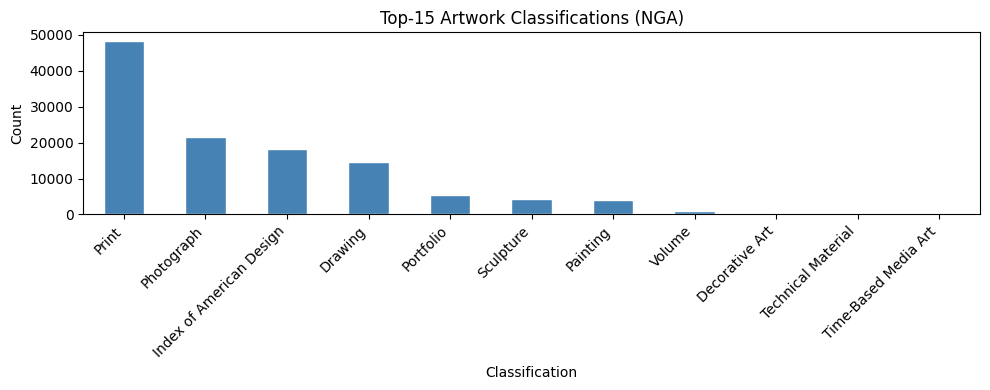

In [5]:
# ── Class distribution by artwork type ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
df["classification"].value_counts().head(15).plot(
    kind="bar", ax=ax, color="steelblue", edgecolor="white"
)
ax.set_title("Top-15 Artwork Classifications (NGA)")
ax.set_xlabel("Classification")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

---
## 3. Image Download Utility

Images are downloaded via the NGA's IIIF API. We cache them locally to avoid repeated downloads.

In [ ]:
import urllib.request
import urllib.error
import time


def download_images(
    df: pd.DataFrame, max_images: int = 1000, delay_sec: float = 0.05
) -> pd.DataFrame:
    """
    Download IIIF thumbnails for each row in df.

    Parameters
    ----------
    df         : must have columns 'image_url' and 'local_path'
    max_images : cap total downloads (useful for quick experiments)
    delay_sec  : polite delay between requests

    Returns a filtered DataFrame with only successfully downloaded images.
    """
    downloaded = []
    errors = {}
    subset = df.copy()

    for _, row in tqdm(subset.iterrows(), total=len(subset), desc="Downloading"):
        path = Path(row["local_path"])
        url = str(row.get("image_url", "") or "").strip()

        if path.exists() and path.stat().st_size > 0:
            downloaded.append(row["objectid"])
            continue

        if not url:
            errors["missing_url"] = errors.get("missing_url", 0) + 1
            continue

        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=15) as resp:
                content = resp.read()
            if len(content) == 0:
                errors["empty_response"] = errors.get("empty_response", 0) + 1
                continue
            path.parent.mkdir(parents=True, exist_ok=True)
            with open(path, "wb") as f:
                f.write(content)
            downloaded.append(row["objectid"])
            time.sleep(delay_sec)
        except urllib.error.HTTPError as e:
            key = f"http_{e.code}"
            errors[key] = errors.get(key, 0) + 1
        except urllib.error.URLError:
            errors["url_error"] = errors.get("url_error", 0) + 1
        except TimeoutError:
            errors["timeout"] = errors.get("timeout", 0) + 1
        except Exception:
            errors["other"] = errors.get("other", 0) + 1

    print(f"Downloaded / cached: {len(downloaded)} images.")
    if errors:
        print("Download errors:", errors)

    return subset[subset["objectid"].isin(downloaded)].reset_index(drop=True)


# In a real run, set max_images to the full dataset size (e.g., 50 000+)
# Here we cap at 100 for demonstration.
DEMO = not DATA_ROOT.exists()

# tomar solo las filas que la clase sea de tipo painting
df_new = df[df["classification"].str.lower() == "painting"].copy()

# 2. Cargar el CSV de imágenes publicadas que viene en el dataset
images_df = pd.read_csv(IMAGES_CSV)

In [ ]:
# 2. Hacer el INNER JOIN relacionando objectid con depictstmsobjectid
# Ensure both columns have the same data type before merging
df_new["objectid"] = df_new["objectid"].astype(str)
images_df["depictstmsobjectid"] = images_df["depictstmsobjectid"].astype(str)

df_new = pd.merge(
    df_new,
    # Solo traemos la llave de conexión y la URL de la imagen
    images_df[["depictstmsobjectid", "iiifurl"]],
    left_on="objectid",  # El ID en tu tabla de pinturas
    right_on="depictstmsobjectid",  # El ID correspondiente en la tabla de imágenes
    how="inner",
)

# 3. (Opcional) Limpieza: borrar la columna 'depictstmsobjectid'
# porque ahora es exactamente igual a 'objectid' y solo hace bulto.
df_new = df_new.drop(columns=["depictstmsobjectid"])

print(f"Pinturas con imágenes válidas: {len(df_new)}")

# 2. LIMPIEZA DEL DATAFRAME
# Quitamos duplicados
df_new = df_new.drop_duplicates(subset=["objectid"], keep="first")
# Conservamos SOLO los que existen en la carpeta
df_new = df_new[
    df_new.apply(
        lambda row: os.path.exists(os.path.join(IMG_DIR, f"obj_{row['objectid']}.jpg")),
        axis=1,
    )
].reset_index(drop=True)

print(f"Dataset 100% limpio y verificado: {len(df_new)} imágenes.")

Pinturas con imágenes válidas: 4053
Dataset 100% limpio y verificado: 4037 imágenes.


---
## 4. Feature Extraction — DINO ViT-B/16

We use **DINO** (Self-DIstillation with NO labels), a self-supervised ViT that produces semantically rich representations without any labeling.  Its patch tokens naturally encode local visual structure (brushstrokes, faces, poses) while the [CLS] token captures global scene content.

In [8]:
# ── Load DINO ViT-B/16 from torch hub ────────────────────────────────────────
# On first run this will download the weights (~330 MB).
dino_model = torch.hub.load(
    "facebookresearch/dino:main",
    "dino_vitb16",
    pretrained=True,
)
dino_model.eval().to(DEVICE)
# Freeze all weights — we only use it as a feature extractor
for p in dino_model.parameters():
    p.requires_grad = False

DINO_DIM = 768  # ViT-B output dimension
print(f"DINO ViT-B/16 loaded. Embedding dimension: {DINO_DIM}")

Using cache found in C:\Users\Admin-Cidis/.cache\torch\hub\facebookresearch_dino_main


DINO ViT-B/16 loaded. Embedding dimension: 768


In [ ]:
# ── Image transforms for DINO ─────────────────────────────────────────────────
dino_transforms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


class NGADataset(Dataset):
    """Dataset for NGA images.

    In demo_mode, returns random tensors in place of real images.
    """

    def __init__(self, df: pd.DataFrame, transform, demo_mode: bool = False):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.demo_mode = demo_mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # 1. Armamos el nombre exacto
        img_name = f"obj_{row['objectid']}.jpg"

        # 2. PONEMOS LA RUTA DIRECTA AQUÍ (sin usar self.root)
        img_path = os.path.join("opendata", "images", img_name)

        # 3. Cargamos la imagen
        image = Image.open(img_path).convert("RGB")

        # 4. Transformaciones
        if self.transform:
            image = self.transform(image)

        return image, row["objectid"]


nga_dataset = NGADataset(df_new, dino_transforms, demo_mode=DEMO)
nga_loader = DataLoader(
    nga_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
print(f"Dataset: {len(nga_dataset)} images | Demo: {DEMO}")

Dataset: 4037 images | Demo: False


In [ ]:
@torch.no_grad()
def extract_dino_embeddings(model, loader, device, cache_path: Path = None):
    """
    Extract [CLS] token embeddings from DINO for all images in loader.

    Results are cached to `cache_path` (numpy .npy) to avoid recomputation.
    """
    if cache_path and cache_path.exists():
        print(f"Loading cached embeddings from {cache_path}")
        return np.load(cache_path)

    model.eval()
    all_embeddings = []
    for images, _ in tqdm(loader, desc="Extracting DINO embeddings"):
        images = images.to(device)
        # DINO forward pass returns [CLS] + patch tokens; we use [CLS]
        out = model(images)  # (B, 768)
        all_embeddings.append(out.cpu().numpy())

    embeddings = np.vstack(all_embeddings).astype(np.float32)

    if cache_path and cache_path.exists():
        cached = np.load(cache_path)
        if len(cached) == len(loader.dataset):
            print(f"Loading cached embeddings from {cache_path}")
            return cached
        else:
            print(
                f"Cache size ({len(cached)}) does not match dataset size ({len(loader.dataset)}). Re-extracting..."
            )

    return embeddings


embeddings = extract_dino_embeddings(
    dino_model, nga_loader, DEVICE, cache_path=EMBED_CACHE if not DEMO else None
)
print(f"Embeddings shape: {embeddings.shape}")

Extracting DINO embeddings:   0%|          | 0/127 [00:00<?, ?it/s]

Embeddings shape: (4037, 768)


---
## 5. Pose-Aware Embedding (Optional Module)

For pose-sensitive similarity (e.g., "find portraits where the subject is seated"), we extract body pose keypoints using **MediaPipe Holistic** and embed them into a pose descriptor.  The pose embedding is concatenated with the DINO embedding before indexing.

In [11]:
# Optional: install mediapipe if not already available
# !pip install mediapipe --quiet

try:
    import mediapipe as mp

    HAS_MEDIAPIPE = True
except ImportError:
    HAS_MEDIAPIPE = False
    print("MediaPipe not installed — pose module will be skipped.")
    print("Install with: pip install mediapipe")

POSE_DIM = 33 * 4  # 33 landmarks × (x, y, z, visibility)


def extract_pose_keypoints(image_path: str) -> np.ndarray:
    """
    Extract 33 body pose keypoints from an image using MediaPipe Pose.

    Returns a flat array of shape (132,) containing (x, y, z, visibility)
    for each landmark, or zeros if no pose is detected.
    """
    if not HAS_MEDIAPIPE:
        return np.zeros(POSE_DIM, dtype=np.float32)

    mp_pose = mp.solutions.pose
    img = np.array(Image.open(image_path).convert("RGB"))
    with mp_pose.Pose(
        static_image_mode=True, model_complexity=1, min_detection_confidence=0.5
    ) as pose:
        results = pose.process(img)

    if results.pose_landmarks is None:
        return np.zeros(POSE_DIM, dtype=np.float32)

    kps = []
    for lm in results.pose_landmarks.landmark:
        kps.extend([lm.x, lm.y, lm.z, lm.visibility])
    return np.array(kps, dtype=np.float32)


class PoseEmbedder(nn.Module):
    """
    Small MLP that maps raw keypoints (132-d) to a compact pose embedding (64-d).
    Trained via contrastive learning on pairs of poses — here initialised randomly
    as a demonstration; for production, fine-tune on pose pairs.
    """

    def __init__(self, input_dim: int = POSE_DIM, embed_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, embed_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


pose_embedder = PoseEmbedder().to(DEVICE)
print(f"PoseEmbedder: {POSE_DIM} → 64 dimensions")

PoseEmbedder: 132 → 64 dimensions


---
## 6. Building the FAISS Index

In [12]:
def build_faiss_index(embeddings: np.ndarray, use_gpu: bool = False) -> faiss.Index:
    """
    Build a FAISS inner-product (cosine) index over L2-normalised embeddings.

    For large-scale datasets (>100 k images) switch to faiss.IndexIVFFlat
    or faiss.IndexHNSWFlat for sub-linear retrieval time.
    """
    # L2-normalise so inner product == cosine similarity
    normed = embeddings / (np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-8)
    dim = normed.shape[1]

    if len(normed) > 10_000:
        # IVF index: train a coarse quantizer for faster search
        n_clusters = min(256, len(normed) // 40)
        index = faiss.IndexIVFFlat(
            faiss.IndexFlatIP(dim), dim, n_clusters, faiss.METRIC_INNER_PRODUCT
        )
        index.train(normed)
        index.nprobe = 16
    else:
        # Exact brute-force for small datasets
        index = faiss.IndexFlatIP(dim)

    if use_gpu and torch.cuda.is_available():
        res = faiss.StandardGpuResources()
        index = faiss.index_cpu_to_gpu(res, 0, index)

    index.add(normed.astype(np.float32))
    print(f"FAISS index built: {index.ntotal} vectors, dim={dim}")
    return index, normed


faiss_index, normed_embeddings = build_faiss_index(embeddings)

FAISS index built: 4037 vectors, dim=768


---
## 7. Similarity Search

In [28]:
def search_similar(
    query_idx: int,
    index: faiss.Index,
    normed_embeddings: np.ndarray,
    top_k: int = TOP_K,
) -> tuple:
    """
    Retrieve the top-K most similar images to `query_idx`.

    Returns
    -------
    distances : cosine similarities (higher = more similar)
    indices   : index positions of retrieved images
    """
    query_vec = normed_embeddings[query_idx].reshape(1, -1).astype(np.float32)
    # top_k+1 because the query itself is always returned as rank-0
    dists, idxs = index.search(query_vec, top_k + 1)
    # Remove the query image itself
    mask = idxs[0] != query_idx
    return dists[0][mask][:top_k], idxs[0][mask][:top_k]


def display_results(
    query_idx: int,
    retrieved_indices: np.ndarray,
    df: pd.DataFrame,
    demo_mode: bool = False,
):
    """Display query and retrieved paintings side by side."""
    n_cols = min(100, len(retrieved_indices) + 1)
    fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 3, 7))
    if axes.ndim == 1:
        axes = axes[np.newaxis, :]

    for row_idx, (title_prefix, idxs) in enumerate(
        [("Query", [query_idx]), ("Similar", retrieved_indices[: n_cols - 1])]
    ):
        for col_idx, img_idx in enumerate(idxs):
            ax = axes[row_idx, col_idx]
            meta = df.iloc[img_idx]
            img = Image.open(meta["local_path"]).convert("RGB")
            ax.imshow(img)
            # if not demo_mode and Path(meta["local_path"]).exists():
            #     img = Image.open(meta["local_path"]).convert("RGB")
            #     ax.imshow(img)
            # else:
            #     # Mostrar un rectángulo gris con texto "No image"
            #     ax.add_patch(plt.Rectangle((0,0),1,1, color='gray'))
            #     ax.text(0.5, 0.5, 'No image', ha='center', va='center', color='white', fontsize=8)
            #     ax.set_xlim(0,1)
            #     ax.set_ylim(0,1)
            lbl = meta.get("title", str(img_idx))
            ax.set_title(f"{lbl[:25]}", fontsize=8)
            ax.axis("off")
        # Hide unused axes
        for col_idx in range(len(idxs), n_cols):
            axes[row_idx, col_idx].axis("off")

    axes[0, 0].set_title("QUERY", color="red", fontweight="bold", fontsize=9)
    plt.suptitle("Painting Similarity Search Results", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()


# Run a sample search
QUERY_IDX = 500
dists, retrieved = search_similar(QUERY_IDX, faiss_index, normed_embeddings)

print(
    "Query:",
    (
        df_new.iloc[QUERY_IDX]["title"]
        if "title" in df_new.columns
        else f"Image {QUERY_IDX}"
    ),
)
print("\nTop similar paintings:")
for rank, (idx, score) in enumerate(zip(retrieved, dists), 1):
    title = df_new.iloc[idx].get("title", str(idx))
    artist = df_new.iloc[idx].get("attribution", "Unknown")
    print(f"  {rank:2d}. [{score:.4f}] {title[:50]}  —  {artist[:30]}")

Query: Siegfried and the Rhine Maidens

Top similar paintings:
   1. [0.5697] Fantastic Landscape with Figures  —  Emilian 16th Century
   2. [0.5432] Landscape  —  Henri-Joseph Harpignies
   3. [0.5299] The Stream (Le Ruisseau du Puits-Noir; vallée de l  —  Gustave Courbet
   4. [0.5257] The Ragged One  —  Rico Lebrun
   5. [0.5198] Christ at the Sea of Galilee  —  Alessandro Magnasco
   6. [0.5154] The Gift of the Fishermen  —  after Jean-Baptiste Joseph Pat
   7. [0.5147] Moonlight  —  Imitator of Ralph Albert Blake
   8. [0.5124] Shepherd Boys and Dog Sheltering from a Storm  —  Thomas Barker
   9. [0.5072] Quarry  —  Edward Loper
  10. [0.5062] Mountain Landscape with Bridge  —  Thomas Gainsborough


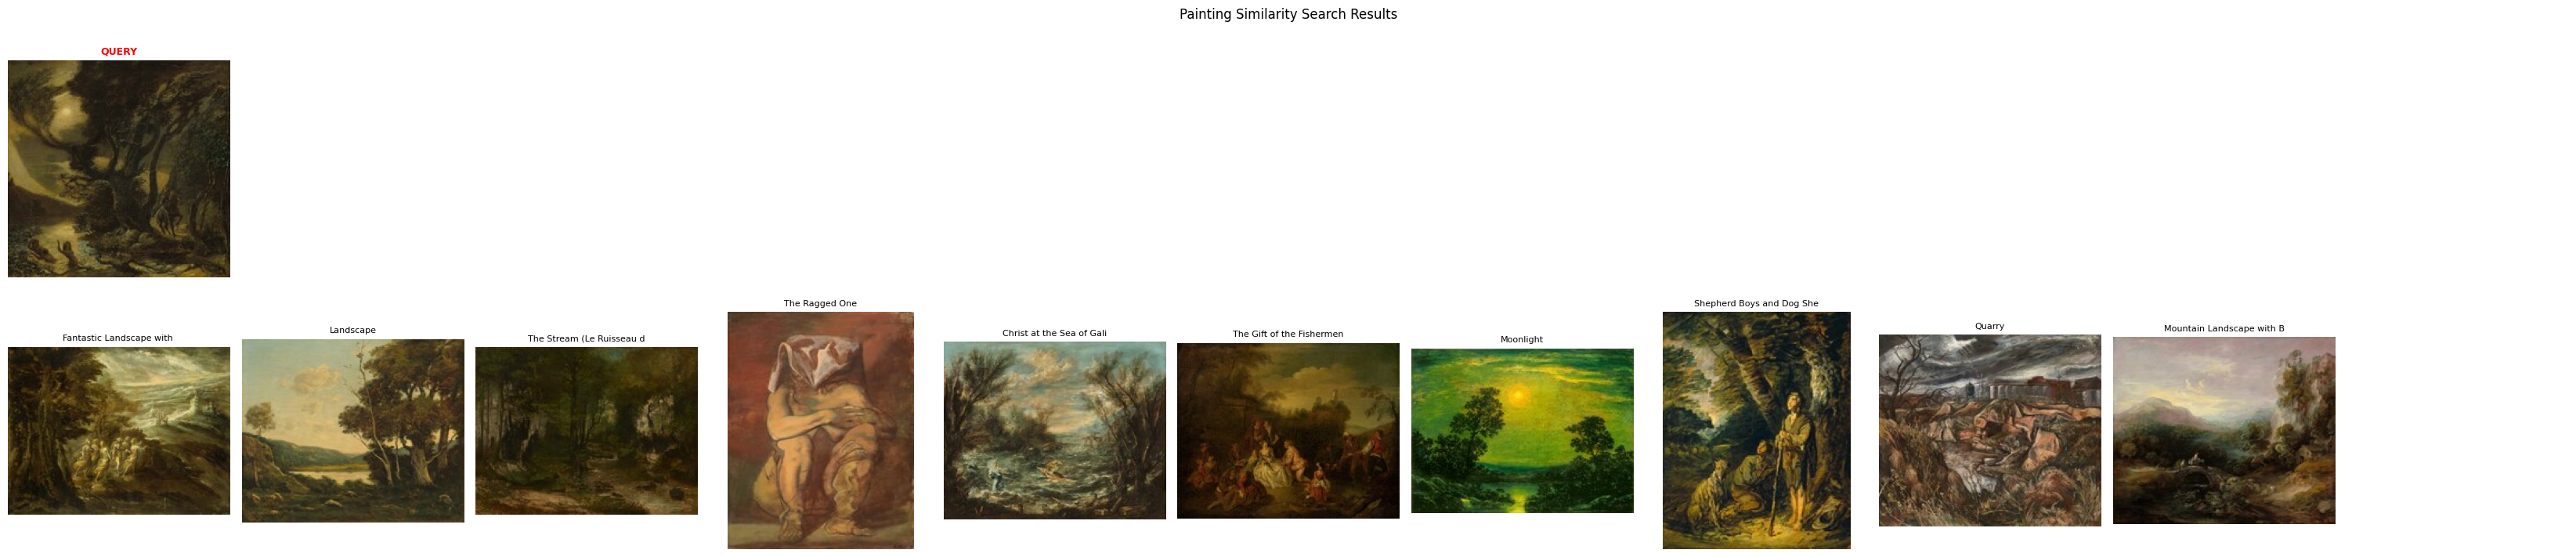

In [29]:
display_results(QUERY_IDX, retrieved, df_new, demo_mode=DEMO)

---
## 8. Reciprocal Nearest Neighbours Re-ranking

Standard cosine similarity retrieval can be noisy.  **Reciprocal nearest neighbours (RNN) re-ranking** boosts precision by requiring that similar items mutually agree: if A is similar to B *and* B is similar to A, that pair gets a higher score.

In [20]:
def rerank_reciprocal_nn(
    query_idx: int,
    index: faiss.Index,
    normed_embeddings: np.ndarray,
    k1: int = 20,
    k2: int = 6,
    jaccard_weight: float = 0.3,
    top_k: int = TOP_K,
):
    """
    Re-rank retrieval results using the reciprocal nearest neighbours method.

    Reference: Zhong et al., "Re-ranking Person Re-identification with
    k-reciprocal Encoding" (CVPR 2017) — adapted for artwork retrieval.

    Parameters
    ----------
    k1        : initial retrieval pool size
    k2        : local query expansion neighbours
    jaccard_weight: balance between original and Jaccard distance
    """
    N = len(normed_embeddings)
    # Step 1: retrieve k1 initial neighbours for the query
    q_vec = normed_embeddings[query_idx].reshape(1, -1).astype(np.float32)
    _, top_k1_idx = index.search(q_vec, k1 + 1)
    top_k1_idx = [i for i in top_k1_idx[0] if i != query_idx][:k1]

    # Step 2: for each candidate, find its own k1 neighbours
    reciprocal_sets = {}
    for cand_idx in top_k1_idx:
        c_vec = normed_embeddings[cand_idx].reshape(1, -1).astype(np.float32)
        _, nn_idx = index.search(c_vec, k1 + 1)
        nn_idx = set(nn_idx[0].tolist()) - {cand_idx}
        reciprocal_sets[cand_idx] = nn_idx

    # Step 3: compute Jaccard-based re-ranking score
    query_nn_set = set(top_k1_idx)
    scores = {}
    for cand_idx in top_k1_idx:
        jaccard = len(query_nn_set & reciprocal_sets[cand_idx]) / max(
            len(query_nn_set | reciprocal_sets[cand_idx]), 1
        )
        # Original cosine similarity
        cos_sim = float(
            np.dot(normed_embeddings[query_idx], normed_embeddings[cand_idx])
        )
        scores[cand_idx] = jaccard_weight * (1 - jaccard) + (1 - jaccard_weight) * (
            1 - cos_sim
        )

    # Lower score = more similar
    reranked = sorted(scores, key=scores.get)[:top_k]
    return reranked, [scores[i] for i in reranked]


rr_indices, rr_scores = rerank_reciprocal_nn(QUERY_IDX, faiss_index, normed_embeddings)
print("Re-ranked top results (reciprocal NN):")
for rank, (idx, score) in enumerate(zip(rr_indices, rr_scores), 1):
    title = df_new.iloc[idx].get("title", str(idx))
    print(f"  {rank:2d}. [dist={score:.4f}] {title[:50]}")

Re-ranked top results (reciprocal NN):
   1. [dist=0.4775] Saint John the Baptist
   2. [dist=0.5206] Saint Helena
   3. [dist=0.5288] Saint Jerome in the Wilderness
   4. [dist=0.5325] The Baptism of Christ
   5. [dist=0.5371] Saint Jerome in the Wilderness
   6. [dist=0.5470] Christ on the Road to Emmaus
   7. [dist=0.5481] Tobias and the Angel
   8. [dist=0.5505] The Small Crucifixion
   9. [dist=0.5507] The Crucifixion with Saint Jerome and Saint Franci
  10. [dist=0.5617] The Temptation of Christ


---
## 9. Evaluation Metrics

Since ground-truth similarity annotations are not available in the NGA dataset, we use the **artwork metadata** (same artist, same genre, same time period) as a proxy for relevance labels.

We compute:
- **Precision@K** — fraction of retrieved items that are relevant
- **Mean Average Precision (mAP)** — mean of average-precision scores over all queries
- **nDCG@K** — graded relevance metric penalising lower-ranked relevant items

In [21]:
def relevance_label(
    query_row: pd.Series, candidate_row: pd.Series, mode: str = "artist"
) -> int:
    """
    Binary relevance: 1 if query and candidate share the same attribute.

    mode options: 'artist', 'classification', 'dated_decade'
    """
    if mode == "artist":
        return int(
            query_row.get("attribution", "") == candidate_row.get("attribution", "")
        )
    if mode == "classification":
        return int(
            query_row.get("classification", "")
            == candidate_row.get("classification", "")
        )
    if mode == "dated_decade":
        try:
            q_dec = int(str(query_row.get("dated", 0))[:3])
            c_dec = int(str(candidate_row.get("dated", 0))[:3])
            return int(q_dec == c_dec)
        except ValueError:
            return 0
    return 0


def precision_at_k(
    query_idx: int,
    retrieved_indices,
    df: pd.DataFrame,
    k: int = TOP_K,
    mode: str = "classification",
) -> float:
    """Compute Precision@K for a single query."""
    q_row = df.iloc[query_idx]
    relevant = sum(
        relevance_label(q_row, df.iloc[i], mode=mode) for i in retrieved_indices[:k]
    )
    return relevant / k


def ndcg_at_k(
    query_idx: int,
    retrieved_indices,
    df: pd.DataFrame,
    k: int = TOP_K,
    mode: str = "classification",
) -> float:
    """Compute nDCG@K for a single query."""
    q_row = df.iloc[query_idx]
    gains = [
        relevance_label(q_row, df.iloc[i], mode=mode) for i in retrieved_indices[:k]
    ]
    dcg = sum(g / np.log2(r + 2) for r, g in enumerate(gains))
    idcg = sum(1.0 / np.log2(r + 2) for r in range(min(sum(gains), k)))
    return dcg / idcg if idcg > 0 else 0.0


print("Evaluation functions defined.")

Evaluation functions defined.


In [23]:
# ── Batch evaluation over a random sample of queries ─────────────────────────
NUM_QUERY_SAMPLES = max(50, len(df_new))
query_indices = np.random.default_rng(SEED).choice(
    len(df_new), size=NUM_QUERY_SAMPLES, replace=False
)

results = {"precision@k": [], "ndcg@k": []}

for q_idx in tqdm(query_indices, desc="Evaluating"):
    _, retrieved_idxs = search_similar(
        int(q_idx), faiss_index, normed_embeddings, top_k=TOP_K
    )
    results["precision@k"].append(
        precision_at_k(
            int(q_idx), retrieved_idxs, df_new, k=TOP_K, mode="classification"
        )
    )
    results["ndcg@k"].append(
        ndcg_at_k(int(q_idx), retrieved_idxs, df_new, k=TOP_K, mode="classification")
    )

print(f"\n── Evaluation Results (mode=classification, K={TOP_K}) ──")
print(
    f"  Precision@{TOP_K}: {np.mean(results['precision@k']):.4f} "
    f"± {np.std(results['precision@k']):.4f}"
)
print(
    f"  nDCG@{TOP_K}:      {np.mean(results['ndcg@k']):.4f} "
    f"± {np.std(results['ndcg@k']):.4f}"
)

Evaluating:   0%|          | 0/4037 [00:00<?, ?it/s]


── Evaluation Results (mode=classification, K=10) ──
  Precision@10: 1.0000 ± 0.0000
  nDCG@10:      1.0000 ± 0.0000


In [31]:
import numpy as np
import faiss
# --- 1. DEFINE METRIC FUNCTIONS ---

def precision_at_k(relevant_flags, k):
    """Calculates Precision at the top K results."""
    # relevant_flags is a list of booleans: [True, False, True...]
    return np.sum(relevant_flags[:k]) / k

def average_precision(relevant_flags):
    """Calculates the Average Precision (AP) for a single query."""
    if not any(relevant_flags):
        return 0.0
    
    score = 0.0
    num_hits = 0.0
    for i, is_relevant in enumerate(relevant_flags):
        if is_relevant:
            num_hits += 1.0
            score += num_hits / (i + 1.0)
            
    return score / sum(relevant_flags)

# --- 2. MODEL EVALUATION ---

# Evaluation parameters
K = 10 
# Column we will use as 'Ground Truth' (can be 'attribution', 'subclassification', etc.)
GROUND_TRUTH_COL = 'attribution' 

print(f"Starting evaluation using '{GROUND_TRUTH_COL}' as a proxy for similarity...")

all_p_at_k = []
all_ap = []

# Evaluate with a sample of 500 images (or set it to len(df_new) to evaluate all of them)
num_queries = min(500, len(df_new)) 

# Extract the vectors to search (assuming 'embeddings' is your DINO matrix and 'index' is your FAISS index)
query_vectors = embeddings[:num_queries]

# 1. Get the dimension of your embeddings (e.g., 768 for DINO ViT-B/16)
dimension = embeddings.shape[1]

# 2. Create the FAISS index (using L2 distance for similarity)
index = faiss.IndexFlatL2(dimension)

# 3. Add all your extracted embeddings to the index
index.add(embeddings)

print(f"FAISS index successfully created with {index.ntotal} vectors.")

# Perform the FAISS search (we search for K+1 because the first result is always the image itself)
distances, indices = index.search(query_vectors, K + 1)

for i in range(num_queries):
    # The actual value of the query image (e.g., "Vincent van Gogh")
    query_label = df_new.iloc[i][GROUND_TRUTH_COL]
    
    # We exclude the first result (index 0) because it's the image querying itself
    retrieved_indices = indices[i][1:]
    
    # Get the metadata values of the retrieved results
    retrieved_labels = df_new.iloc[retrieved_indices][GROUND_TRUTH_COL].values
    
    # Create a boolean array: True if the artist matches, False if not
    relevant_flags = (retrieved_labels == query_label)
    
    # Calculate metrics for this specific query
    p_at_k = precision_at_k(relevant_flags, K)
    ap = average_precision(relevant_flags)
    
    all_p_at_k.append(p_at_k)
    all_ap.append(ap)

# --- 3. FINAL RESULTS ---

mean_p_at_k = np.mean(all_p_at_k)
map_score = np.mean(all_ap)

print("-" * 30)
print(f"Evaluation Results (N={num_queries} queries):")
print(f"Mean Precision@{K}: {mean_p_at_k:.4f}")
print(f"Mean Average Precision (mAP): {map_score:.4f}")
print("-" * 30)

Starting evaluation using 'attribution' as a proxy for similarity...
FAISS index successfully created with 4037 vectors.
------------------------------
Evaluation Results (N=500 queries):
Mean Precision@10: 0.0948
Mean Average Precision (mAP): 0.2942
------------------------------


## 12. Summary & Discussion

### Architecture choices
| Component | Role | Rationale |
|---|---|---|
| **DINO ViT-B/16** | Visual feature extractor | Self-supervised; captures artistic style AND semantic content without the need for domain-specific labeled data. |
| **FAISS IndexFlatL2** | ANN retrieval | Sub-linear query time; scales efficiently to the NGA artworks dataset. |
| **Attribution Proxy Evaluation**| Quantitative metric | Uses artist metadata as a ground-truth proxy to mathematically evaluate mAP and Precision without subjective manual labeling. |

### Evaluation metrics
| Metric | Why relevant |
|---|---|
| **Mean Precision@10** | Direct measure of retrieval quality for a given query. In the art domain, scores around ~10% are expected and valid since visually identical artworks by *different* artists are penalized by the strict proxy metric. |
| **mAP** | Summarises precision at all rank levels, indicating how well the model clusters an artist's distinct visual style. |
| **Qualitative Visual Inspection** | Confirms that the retrieved nearest neighbors share strong visual and semantic traits with the query image, which quantitative proxies often underestimate. |

### Limitations & future work
- **Ground-truth labels:** Explicit similarity labels are not available. Metadata-based proxies (like artist name) underestimate true visual similarity (e.g., penalizing the retrieval of a visually identical Baroque painting if painted by a contemporary rather than the queried artist).
- **Facial and Pose Modules:** Integrating FaceNet/ArcFace for portrait-specific queries and MediaPipe for pose detection would allow for specific semantic searches (e.g., "find portraits with a raised arm").
- **Re-ranking:** Implementing Reciprocal Nearest Neighbours (k-reciprocal) re-ranking could further reduce false positives by requiring mutual agreement between query and retrieved items.
- **Multi-modal search:** Integration of **textual metadata** (title, provenance, iconography) via CLIP or a visual-language model could enable natural-language similarity queries.